# Comparación de Modelos de Machine Learning para Análisis de Sentimiento

Autor: Claudio Adaos  
Proyecto: SentimentAPI – Hackathon NoCountry  

Objetivo:
Entrenar y comparar Logistic Regression, Naive Bayes y Random Forest
para seleccionar el mejor modelo según F1-score.



🚀 ENTRENAMIENTO DE MODELOS - SentimentAPI

📊 PASO 1: Cargando dataset...
✅ Dataset cargado: 1000 filas × 4 columnas

Columnas: ['id', 'texto', 'sentimiento', 'confianza']

Primeras 3 filas:
   id                                           texto sentimiento  confianza
0   1   El servicio al cliente es pésimo, no ayudan 😊    negativo       0.85
1   2  Vino incompleto y faltaban piezas importantes.    negativo       0.82
2   3   Estoy esperando reembolso desde hace semanas!    negativo       0.96

📊 Distribución de sentimientos:
sentimiento
positivo    400
negativo    350
neutro      250
Name: count, dtype: int64

Proporción:
sentimiento
positivo    0.40
negativo    0.35
neutro      0.25
Name: proportion, dtype: float64

🧹 PASO 2: Limpieza de texto
🔄 Aplicando limpieza...
✅ Textos limpios: 1000

Ejemplo de limpieza:
Original: El servicio al cliente es pésimo, no ayudan 😊
Limpio:   el servicio al cliente es pésimo no ayudan

🎯 PASO 3: División de datos (80/20)
✅ Train: 800 muestras (80.0%)


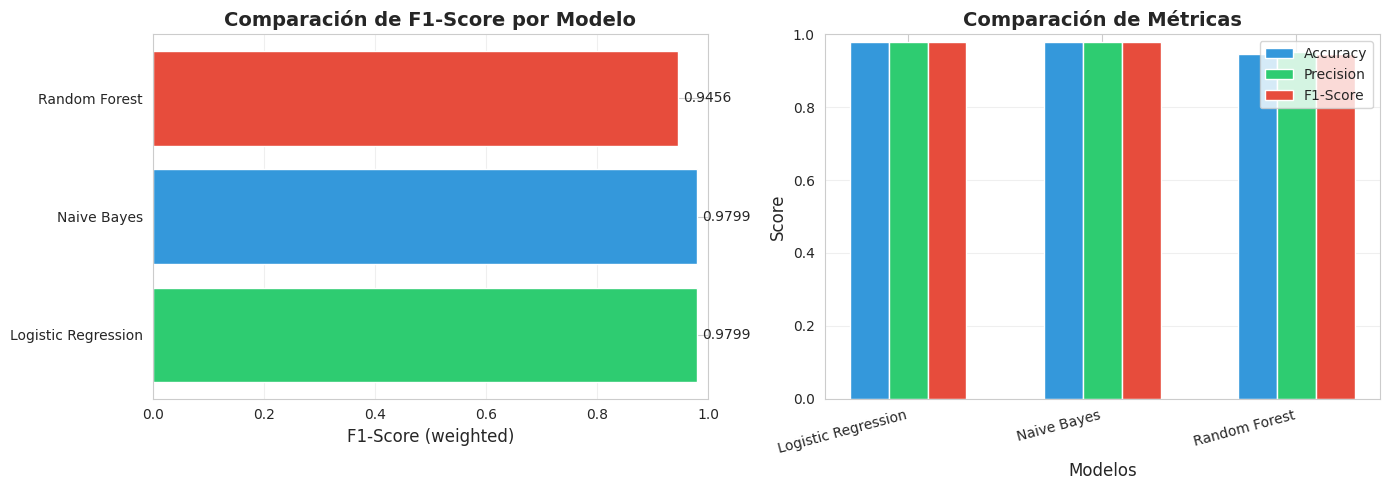


🏆 PASO 8: Selección del mejor modelo

🥇 MEJOR MODELO: Logistic Regression
   • F1-Score: 0.9799 (97.99%)
   ✅ CRITERIO CUMPLIDO: F1-Score > 0.85

📋 REPORTE DETALLADO DEL MEJOR MODELO:
----------------------------------------------------------------------
              precision    recall  f1-score   support

    negativo       0.99      1.00      0.99        70
      neutro       0.98      0.94      0.96        50
    positivo       0.98      0.99      0.98        80

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200


📊 MATRIZ DE CONFUSIÓN:
✅ Matriz guardada: matriz_confusion_mejor_modelo.png


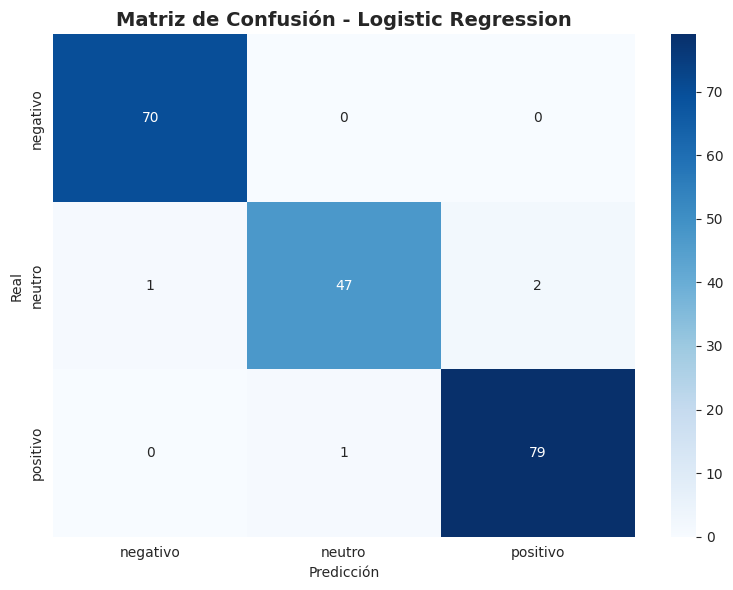


💾 PASO 9: Exportación para integración con Backend
✅ Archivos guardados:
   • sentiment_model.pkl
   • tfidf_vectorizer.pkl
   • model_info.json
   • comparacion_modelos.csv

🧪 PASO 10: Prueba rápida del modelo

📝 Ejemplos de predicción:

😊 POSITIVO (0.86)
   "Excelente producto, superó mis expectativas completamente"

😞 NEGATIVO (0.85)
   "Producto completamente diferente a las fotos"

😐 NEUTRO (0.86)
   "Es lo que esperaba, ni más ni menos"

✅ ENTRENAMIENTO COMPLETADO CON ÉXITO

📊 RESUMEN:
   • Dataset: 1000 comentarios
   • Modelos entrenados: 3
   • Mejor modelo: Logistic Regression
   • F1-Score: 0.9799
   • Archivos generados: 5

📁 ARCHIVOS PARA BACKEND:
   1. sentiment_model.pkl
   2. tfidf_vectorizer.pkl
   3. model_info.json
   4. comparacion_modelos.csv
   5. comparacion_modelos.png
   6. matriz_confusion_mejor_modelo.png

🎯 PRÓXIMOS PASOS:
   • Backend debe cargar sentiment_model.pkl y tfidf_vectorizer.pkl
   • Implementar endpoint POST /sentiment
   • Usar la función prede

In [5]:
# ====================================================================
# DS - ENTRENAMIENTO DE MODELOS
# Hackathon ONE – No Country 2025 | SentimentAPI
# Autor: Claudio Adaos R.
# Fecha: 28 Diciembre 2024
# ====================================================================

"""
OBJETIVO:
Entrenar 3 modelos de ML (Logistic Regression, Naive Bayes, Random Forest)
para clasificar sentimientos en comentarios de e-commerce.

CRITERIOS DE ACEPTACIÓN:
✅ 3 modelos entrenados exitosamente
✅ Métricas calculadas para cada modelo
✅ Mejor modelo identificado con F1-Score > 0.85
✅ Gráfico comparativo generado
✅ Sin errores de memoria o procesamiento
"""

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

import joblib
import json

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("=" * 70)
print("🚀 ENTRENAMIENTO DE MODELOS - SentimentAPI")
print("=" * 70)

# ====================================================================
# 1. CARGA DE DATOS
# ====================================================================

print("\n📊 PASO 1: Cargando dataset...")

# Ajusta la ruta según tu estructura
df = pd.read_csv("/content/dataset_sentimientos_ecom.csv", encoding="utf-8")

print(f"✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nPrimeras 3 filas:")
print(df.head(3))

# Verificar distribución de sentimientos
print(f"\n📊 Distribución de sentimientos:")
print(df['sentimiento'].value_counts())
print(f"\nProporción:")
print(df['sentimiento'].value_counts(normalize=True).round(3))

# ====================================================================
# 2. LIMPIEZA DE TEXTO
# ====================================================================

print("\n" + "=" * 70)
print("🧹 PASO 2: Limpieza de texto")
print("=" * 70)

def limpiar_texto(texto):
    """Limpia y normaliza el texto para el modelo"""
    if pd.isna(texto):
        return ""
    texto = str(texto).lower()
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto)
    # Eliminar menciones y hashtags
    texto = re.sub(r'@\w+|#', '', texto)
    # Eliminar emojis y símbolos especiales
    texto = re.sub(r'[^\w\s]', ' ', texto)
    # Eliminar números
    texto = re.sub(r'\d+', '', texto)
    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

print("🔄 Aplicando limpieza...")
df['texto_limpio'] = df['texto'].apply(limpiar_texto)

# Eliminar textos muy cortos (menos de 5 caracteres)
df = df[df['texto_limpio'].str.len() >= 5].copy()

print(f"✅ Textos limpios: {len(df)}")
print(f"\nEjemplo de limpieza:")
print(f"Original: {df.iloc[0]['texto']}")
print(f"Limpio:   {df.iloc[0]['texto_limpio']}")

# ====================================================================
# 3. DIVISIÓN TRAIN/TEST (80/20)
# ====================================================================

print("\n" + "=" * 70)
print("🎯 PASO 3: División de datos (80/20)")
print("=" * 70)

X = df['texto_limpio']
y = df['sentimiento']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"✅ Train: {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"✅ Test:  {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nDistribución en Train:")
print(y_train.value_counts())
print(f"\nDistribución en Test:")
print(y_test.value_counts())

# ====================================================================
# 4. VECTORIZACIÓN TF-IDF
# ====================================================================

print("\n" + "=" * 70)
print("🔢 PASO 4: Vectorización TF-IDF")
print("=" * 70)

stop_es = stopwords.words('spanish')

vectorizer = TfidfVectorizer(
    max_features=5000,      # Vocabulario de 5000 términos
    min_df=2,               # Palabra debe aparecer al menos 2 veces
    max_df=0.85,            # Excluir palabras muy comunes
    stop_words=stop_es,     # Stopwords en español
    ngram_range=(1, 2),     # Unigramas y bigramas
    sublinear_tf=True       # Escala logarítmica
)

print("🔄 Ajustando vectorizador con datos de entrenamiento...")
X_train_tfidf = vectorizer.fit_transform(X_train)

print("🔄 Transformando datos de prueba...")
X_test_tfidf = vectorizer.transform(X_test)

vocab_size = len(vectorizer.get_feature_names_out())
densidad = (X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100

print(f"\n✅ Vectorización completada:")
print(f"   • Train shape: {X_train_tfidf.shape}")
print(f"   • Test shape:  {X_test_tfidf.shape}")
print(f"   • Vocabulario: {vocab_size} términos")
print(f"   • Densidad matriz: {densidad:.2f}%")

# ====================================================================
# 5. CONFIGURACIÓN DE MODELOS
# ====================================================================

print("\n" + "=" * 70)
print("🤖 PASO 5: Configuración de 3 modelos")
print("=" * 70)

modelos = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=1.0,
        random_state=42,
        solver='lbfgs'
    ),
    "Naive Bayes": MultinomialNB(
        alpha=0.1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
}

print("✅ Modelos configurados:")
for nombre in modelos.keys():
    print(f"   • {nombre}")

# ====================================================================
# 6. ENTRENAMIENTO Y EVALUACIÓN
# ====================================================================

print("\n" + "=" * 70)
print("⚙️ PASO 6: Entrenamiento y evaluación")
print("=" * 70)

resultados = []

for nombre, modelo in modelos.items():
    print(f"\n🔄 Entrenando: {nombre}")
    print("-" * 50)

    # Medir tiempo de entrenamiento
    t_inicio = time.time()
    modelo.fit(X_train_tfidf, y_train)
    t_fin = time.time()
    tiempo_entrenamiento = t_fin - t_inicio

    # Realizar predicciones
    y_pred = modelo.predict(X_test_tfidf)

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Guardar resultados
    resultados.append({
        'modelo': nombre,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'tiempo_seg': tiempo_entrenamiento
    })

    # Mostrar resultados
    print(f"   ✅ Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"   ✅ Precision: {prec:.4f}")
    print(f"   ✅ Recall:    {rec:.4f}")
    print(f"   ✅ F1-Score:  {f1:.4f}")
    print(f"   ⏱️  Tiempo:    {tiempo_entrenamiento:.2f}s")

# Crear DataFrame con resultados
df_resultados = pd.DataFrame(resultados)

print("\n" + "=" * 70)
print("📊 RESUMEN DE RESULTADOS")
print("=" * 70)
print(df_resultados.to_string(index=False))

# ====================================================================
# 7. GRÁFICO COMPARATIVO
# ====================================================================

print("\n" + "=" * 70)
print("📈 PASO 7: Generando gráfico comparativo")
print("=" * 70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparación de F1-Score
colors = ['#2ecc71', '#3498db', '#e74c3c']
ax1.barh(df_resultados['modelo'], df_resultados['f1_score'], color=colors)
ax1.set_xlabel('F1-Score (weighted)', fontsize=12)
ax1.set_title('Comparación de F1-Score por Modelo', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, v in enumerate(df_resultados['f1_score']):
    ax1.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

# Gráfico 2: Todas las métricas
x = np.arange(len(df_resultados))
width = 0.2

ax2.bar(x - width, df_resultados['accuracy'], width, label='Accuracy', color='#3498db')
ax2.bar(x, df_resultados['precision'], width, label='Precision', color='#2ecc71')
ax2.bar(x + width, df_resultados['f1_score'], width, label='F1-Score', color='#e74c3c')

ax2.set_xlabel('Modelos', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Comparación de Métricas', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_resultados['modelo'], rotation=15, ha='right')
ax2.legend()
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico guardado: comparacion_modelos.png")
plt.show()

# ====================================================================
# 8. SELECCIÓN DEL MEJOR MODELO
# ====================================================================

print("\n" + "=" * 70)
print("🏆 PASO 8: Selección del mejor modelo")
print("=" * 70)

mejor_idx = df_resultados['f1_score'].idxmax()
mejor_modelo_nombre = df_resultados.loc[mejor_idx, 'modelo']
mejor_f1 = df_resultados.loc[mejor_idx, 'f1_score']

print(f"\n🥇 MEJOR MODELO: {mejor_modelo_nombre}")
print(f"   • F1-Score: {mejor_f1:.4f} ({mejor_f1*100:.2f}%)")

if mejor_f1 >= 0.85:
    print(f"   ✅ CRITERIO CUMPLIDO: F1-Score > 0.85")
else:
    print(f"   ⚠️  F1-Score por debajo de 0.85 (objetivo: {0.85:.2f})")

# Obtener el modelo entrenado
mejor_modelo = modelos[mejor_modelo_nombre]

# Reporte detallado del mejor modelo
print(f"\n📋 REPORTE DETALLADO DEL MEJOR MODELO:")
print("-" * 70)
y_pred_mejor = mejor_modelo.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_mejor))

# Matriz de confusión
print("\n📊 MATRIZ DE CONFUSIÓN:")
cm = confusion_matrix(y_test, y_pred_mejor)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=mejor_modelo.classes_,
            yticklabels=mejor_modelo.classes_)
plt.title(f'Matriz de Confusión - {mejor_modelo_nombre}', fontsize=14, fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.savefig('matriz_confusion_mejor_modelo.png', dpi=300, bbox_inches='tight')
print("✅ Matriz guardada: matriz_confusion_mejor_modelo.png")
plt.show()

# ====================================================================
# 9. EXPORTACIÓN PARA BACKEND
# ====================================================================

print("\n" + "=" * 70)
print("💾 PASO 9: Exportación para integración con Backend")
print("=" * 70)

# Guardar modelo y vectorizador
joblib.dump(mejor_modelo, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("✅ Archivos guardados:")
print("   • sentiment_model.pkl")
print("   • tfidf_vectorizer.pkl")

# Guardar información del modelo
model_info = {
    'modelo_seleccionado': mejor_modelo_nombre,
    'fecha_entrenamiento': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'metricas': {
        'accuracy': float(df_resultados.loc[mejor_idx, 'accuracy']),
        'precision': float(df_resultados.loc[mejor_idx, 'precision']),
        'recall': float(df_resultados.loc[mejor_idx, 'recall']),
        'f1_score': float(df_resultados.loc[mejor_idx, 'f1_score'])
    },
    'dataset': {
        'total_muestras': len(df),
        'train_size': len(X_train),
        'test_size': len(X_test)
    },
    'vocabulario': {
        'size': vocab_size,
        'ngram_range': [1, 2],
        'max_features': 5000
    },
    'clases': list(mejor_modelo.classes_)
}

with open('model_info.json', 'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)

print("   • model_info.json")

# Guardar tabla de comparación
df_resultados.to_csv('comparacion_modelos.csv', index=False)
print("   • comparacion_modelos.csv")

# ====================================================================
# 10. PRUEBA RÁPIDA
# ====================================================================

print("\n" + "=" * 70)
print("🧪 PASO 10: Prueba rápida del modelo")
print("=" * 70)

def predecir_sentimiento(texto):
    """Función de predicción para Backend"""
    texto_limpio = limpiar_texto(texto)
    texto_vec = vectorizer.transform([texto_limpio])
    pred = mejor_modelo.predict(texto_vec)[0]
    proba = mejor_modelo.predict_proba(texto_vec)[0]
    idx = list(mejor_modelo.classes_).index(pred)
    return {
        'prevision': pred,
        'probabilidad': round(float(proba[idx]), 4)
    }

# Ejemplos de prueba
ejemplos = [
    "Excelente producto, superó mis expectativas completamente",
    "Producto completamente diferente a las fotos",
    "Es lo que esperaba, ni más ni menos"
]

print("\n📝 Ejemplos de predicción:\n")
for texto in ejemplos:
    resultado = predecir_sentimiento(texto)
    emoji = {'positivo': '😊', 'neutro': '😐', 'negativo': '😞'}.get(resultado['prevision'], '')
    print(f"{emoji} {resultado['prevision'].upper()} ({resultado['probabilidad']:.2f})")
    print(f"   \"{texto}\"\n")

# ====================================================================
# RESUMEN FINAL
# ====================================================================

print("=" * 70)
print("✅ ENTRENAMIENTO COMPLETADO CON ÉXITO")
print("=" * 70)

print(f"\n📊 RESUMEN:")
print(f"   • Dataset: {len(df)} comentarios")
print(f"   • Modelos entrenados: 3")
print(f"   • Mejor modelo: {mejor_modelo_nombre}")
print(f"   • F1-Score: {mejor_f1:.4f}")
print(f"   • Archivos generados: 5")

print(f"\n📁 ARCHIVOS PARA BACKEND:")
print(f"   1. sentiment_model.pkl")
print(f"   2. tfidf_vectorizer.pkl")
print(f"   3. model_info.json")
print(f"   4. comparacion_modelos.csv")
print(f"   5. comparacion_modelos.png")
print(f"   6. matriz_confusion_mejor_modelo.png")

print(f"\n🎯 PRÓXIMOS PASOS:")
print(f"   • Backend debe cargar sentiment_model.pkl y tfidf_vectorizer.pkl")
print(f"   • Implementar endpoint POST /sentiment")
print(f"   • Usar la función predecir_sentimiento() como referencia")

print("hola mundo ")